In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import cvxpy as cp
from PPO_agent import JointBandPolicy, ValueNetCLS
from GBMEnv_LQ_v3 import GBMBandEnvMulti, globalsetting
from Rollout_HJB_box_v1 import compute_delta_box
from RLopt_helpers import clamp01_vec, build_corr_from_pairs, build_cov

globalcfg = globalsetting(
    seed    = 42,
    device  = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    N_ASSETS = 5,
    sigmas   = np.array([0.40, 0.30, 0.12, 0.22, 0.25], dtype=float),
    pair_rhos = {
        (0,1): 0.60,
        (1,3): -0.20,
        (2,4): 0.05,
    },
    DISCOUNT_BY_BANK = True,
    INIT_W0_UNIFORM  = True,
    BAND_SMOOTH_COEF = 0.0,
    TRADE_PEN_COEF   = 0.4,
    ALPHA = 1/5,
    STAGE1_WIDTH_COEF = 0.05,
)
random.seed(globalcfg.seed)
np.random.seed(globalcfg.seed)
torch.manual_seed(globalcfg.seed)

R = build_corr_from_pairs(globalcfg.N_ASSETS, base_rho=0.20, pair_rhos=globalcfg.pair_rhos, make_psd=True)
Cov = build_cov(sigmas=globalcfg.sigmas, R=R, make_psd=True)


target_choices = [0.02, 0.04, 0.06, 0.08]

policy = JointBandPolicy(globalcfg.N_ASSETS, d_model=128, nlayers=2, nhead=4, use_cash_softmax=True)
policy.load_state_dict(torch.load("policy_stage2_B_finetuned.pt", map_location=globalcfg.device))
policy.to(globalcfg.device)
policy.eval()

/opt/homebrew/Caskroom/miniconda/base/envs/my/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


JointBandPolicy(
  (body): JointTransformerBody(
    (token_enc): Linear(in_features=5, out_features=128, bias=True)
    (glob_proj): Linear(in_features=4, out_features=128, bias=False)
    (enc): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.0, inplace=False)
          (dropout2): Dropout(p=0.0, inplace=False)
        )
      )
    )
  )
  (head_m): Linear(in_features=128, out_features=1, bias=True)
  (head_s): Li

In [11]:
# ============================================================
# 1) Annualization helpers (Arithmetic vs Geometric)
# ============================================================
def ann_arith_mean_vol_from_rsimple(rsimple, dt=1/252):
    """
    Arithmetic: mean(r_simple) and std(r_simple)
    """
    r = np.asarray(rsimple, float)
    ann_mean = r.mean() / dt
    ann_vol  = r.std(ddof=1) / np.sqrt(dt)
    return float(ann_mean), float(ann_vol)

def ann_geom_mean_vol_from_rsimple(rsimple, dt=1/252):
    """
    Geometric: mean(log(1+r)) and std(log(1+r))
    """
    r = np.asarray(rsimple, float)
    logret = np.log1p(r)
    ann_mean = logret.mean() / dt
    ann_vol  = logret.std(ddof=1) / np.sqrt(dt)
    return float(ann_mean), float(ann_vol)

# ============================================================
# 2) MV QP solver with "infeasible skip" option
# ============================================================
def mv_weights_target_return(
    Cov, mu_eff, target_ann,
    allow_cash=True,
    solver="OSQP",
    infeasible_policy="skip",  # "skip" or "fallback"
):
    """
    min w^T Cov w
    s.t. mu_eff^T w >= target_ann, w>=0, sum(w)<=1 (cash allowed)

    infeasible_policy:
      - "skip": return None if target_ann > max(mu_eff) (not achievable under long-only+cash)
      - "fallback": invest 100% in argmax(mu_eff)
    """
    mu_eff = np.asarray(mu_eff, float)
    n = len(mu_eff)
    mu_max = float(mu_eff.max())

    if target_ann > mu_max + 1e-12:
        if infeasible_policy == "skip":
            return None
        else:
            ww = np.zeros(n)
            ww[int(np.argmax(mu_eff))] = 1.0
            return ww

    w = cp.Variable(n)
    obj = cp.Minimize(cp.quad_form(w, Cov))
    cons = [w >= 0, mu_eff @ w >= float(target_ann)]
    cons += [cp.sum(w) <= 1.0] if allow_cash else [cp.sum(w) == 1.0]
    prob = cp.Problem(obj, cons)

    try:
        prob.solve(solver=getattr(cp, solver), verbose=False)
    except Exception:
        prob.solve(solver=cp.SCS, verbose=False)

    if w.value is None:
        if infeasible_policy == "skip":
            return None
        ww = np.zeros(n)
        ww[int(np.argmax(mu_eff))] = 1.0
        return ww

    ww = np.maximum(0.0, np.array(w.value).reshape(-1))
    s = float(ww.sum())
    if not allow_cash:
        ww /= (s + 1e-12)
    else:
        if s > 1.0:
            ww /= (s + 1e-12)
    return ww

def compute_levelB_basis_and_width(m_star, Cov, gamma, lam_scalar, eps=1e-12, scale=1.0):
    """
    Returns (U, delta_z) where:
      a* = Q Cov Q,  a* = U diag(eig) U^T
      delta_z_k ∝ (kappa*eig_k / Gamma_kk)^{1/3},  Gamma_kk ≈ gamma*(U^T Cov U)_kk
    """
    m_star = np.asarray(m_star, float).reshape(-1)
    Cov = np.asarray(Cov, float)
    kappa = max(0.0, 1.0 - float(lam_scalar))

    Q = np.diag(m_star) - np.outer(m_star, m_star)
    a = Q @ Cov @ Q
    a = 0.5 * (a + a.T)

    eigvals, U = np.linalg.eigh(a)
    eigvals = np.maximum(eigvals, 0.0)

    Cov_rot = U.T @ Cov @ U
    Gamma_kk = np.maximum(eps, float(gamma) * np.maximum(eps, np.diag(Cov_rot)))

    delta_z = scale * np.power((kappa * eigvals) / Gamma_kk, 1.0/3.0)
    delta_z = np.maximum(delta_z, 0.0)
    return U, delta_z

def run_episode_RL_band_levelB_v2(env_cfg, R, policy, beta, lam_cost, target_ann, seed=2025, T=None, device="cpu",
                               infeasible_policy="skip", mv_solver="OSQP", qp_solver="OSQP",
                               mv_allow_cash=False, force_s_one: bool = False):
    """
    Level B executor evaluation:
      - compute MV center m_star (same as A2)
      - build rotated basis U and z-width prior delta_z (once per episode)
      - per step: get s (or force s≡1), set b_z = 0.95*s*delta_z, then env.step_rotated_box(...)
    Returns: rsimple array or None if infeasible
    """
    cfg2 = env_cfg
    cfg2.seed = int(seed)

    env = GBMBandEnvMulti(cfg=cfg2, R=R)
    N = cfg2.N_ASSETS
    w0 = np.full(N, 1.0 / N) * 0.8
    obs = env.reset(beta=beta, lam=lam_cost, target_ret=target_ann, w0=w0)

    target_ann_eff = float(env.target_ret_ann)
    mu_eff = (cfg2.sigmas**2) * beta
    m_star = mv_weights_target_return(env.Cov, mu_eff, target_ann_eff, allow_cash=mv_allow_cash,
                                      solver=mv_solver, infeasible_policy=infeasible_policy)
    if m_star is None:
        return None

    T = env.T if T is None else int(T)
    rs = []

    lam_scalar = float(env.lam.mean()) if isinstance(env.lam, np.ndarray) else float(env.lam)
    U, delta_z = compute_levelB_basis_and_width(
        m_star=m_star,
        Cov=env.Cov,
        gamma=float(getattr(cfg2, "RISK_GAMMA", 1.0)),
        lam_scalar=lam_scalar,
        scale=1.0,
    )

    for _ in range(T):
        o = np.array(obs, dtype=np.float32)

        # get s from policy (same as A2), or force s≡1
        if force_s_one:
            s = np.ones(N, dtype=float)
        else:
            with torch.no_grad():
                if hasattr(policy, "sample_s_only"):
                    s_t, _, _ = policy.sample_s_only(torch.tensor(o, device=device).unsqueeze(0))
                    s = s_t.squeeze(0).detach().cpu().numpy()
                else:
                    _, s_t, _, _, _ = policy.sample_stage2(torch.tensor(o, device=device).unsqueeze(0))
                    s = s_t.squeeze(0).detach().cpu().numpy()

        b_z = 0.95 * s * delta_z

        obs, r_step, done, r_simple = env.step_rotated_box(
            m=m_star, U=U, b_z=b_z,
            allow_cash=mv_allow_cash,
            solver=qp_solver,
            use_trade_penalty=True
        )
        rs.append(float(r_simple))
        if done:
            break

    return np.array(rs)

def run_episode_MV_daily_frictionless(env_cfg, R, beta, target_ann, seed=2025, T=None,
                                      infeasible_policy="skip", mv_solver="OSQP"):
    cfg2 = env_cfg
    cfg2.seed = int(seed)

    env = GBMBandEnvMulti(cfg=cfg2, R=R)
    N = cfg2.N_ASSETS
    w0 = np.full(N, 1.0 / N) * 0.8
    obs = env.reset(beta=beta, lam=1.0, target_ret=target_ann, w0=w0)

    target_ann_eff = float(env.target_ret_ann)
    mu_eff = (cfg2.sigmas**2) * beta
    w_star = mv_weights_target_return(env.Cov, mu_eff, target_ann_eff, allow_cash=False,
                                      solver=mv_solver, infeasible_policy=infeasible_policy)
    if w_star is None:
        return None

    T = env.T if T is None else int(T)
    rs = []
    for _ in range(T):
        obs, r_step, done, r_simple = env.step(w_star, w_star, use_trade_penalty=False)
        rs.append(float(r_simple))
        if done:
            break
    return np.array(rs)

def run_episode_MV_monthly_heuristic(env_cfg, R, beta, lam_cost, target_ann, seed=2025, rebalance_every=21, T=None,
                                     infeasible_policy="skip", mv_solver="OSQP"):
    cfg2 = env_cfg
    cfg2.seed = int(seed)

    env = GBMBandEnvMulti(cfg=cfg2, R=R)
    N = cfg2.N_ASSETS
    w0 = np.full(N, 1.0 / N) * 0.8
    obs = env.reset(beta=beta, lam=lam_cost, target_ret=target_ann, w0=w0)

    target_ann_eff = float(env.target_ret_ann)
    mu_eff = (cfg2.sigmas**2) * beta
    w_star = mv_weights_target_return(env.Cov, mu_eff, target_ann_eff, allow_cash=False,
                                      solver=mv_solver, infeasible_policy=infeasible_policy)
    if w_star is None:
        return None

    T = env.T if T is None else int(T)
    rs = []
    for t in range(T):
        if (t % rebalance_every) == 0:
            A = w_star; B = w_star
        else:
            A = np.zeros(N); B = np.ones(N)
        obs, r_step, done, r_simple = env.step(A, B, use_trade_penalty=True)
        rs.append(float(r_simple))
        if done:
            break
    return np.array(rs)

def frontier_compare_v5(
    globalcfg, R, policy, targets,
    n_eps=30,
    lam_cost=0.995,
    rebalance_every=21,
    base_seed=2025,
    T_days=252*5,
    beta_mode="fixed",           # "fixed" or "mixed"
    beta_fixed=None,             # np.array(N,)
    beta_low=-0.95, beta_high=0.95,
    infeasible_policy="skip",    # "skip" or "fallback"
    mv_solver="OSQP",
):
    """
    Returns:
      res_arith[strategy][target] = (mean, vol)
      res_geom[strategy][target]  = (mean, vol)
      raw[strategy][target] = list of dicts: {"arith":(m,v), "geom":(m,v)} for each episode
      info: skip counts
    """
    strategies = ["MV_daily_frictionless", "MV_monthly_cost",
                  "RL_band_B",
                  ]
    raw = {s: {t: [] for t in targets} for s in strategies}
    skipped = {s: {t: 0 for t in targets} for s in strategies}

    N = globalcfg.N_ASSETS
    if beta_mode == "fixed":
        if beta_fixed is None:
            beta_fixed = np.ones(N) * 0.5  # default: positive drift regime
        beta_fixed = np.asarray(beta_fixed, float).reshape(N,)

    for j in range(n_eps):
        seed = base_seed + j
        rng = np.random.default_rng(seed)

        if beta_mode == "mixed":
            beta = rng.uniform(beta_low, beta_high, size=N)
        else:
            beta = beta_fixed.copy()

        for t_ann in targets:
            # MV daily (upper)
            rs0 = run_episode_MV_daily_frictionless(
                globalcfg, R, beta, t_ann, seed=seed, T=T_days,
                infeasible_policy=infeasible_policy, mv_solver=mv_solver
            )
            if rs0 is None:
                skipped["MV_daily_frictionless"][t_ann] += 1
            else:
                raw["MV_daily_frictionless"][t_ann].append({
                    "arith": ann_arith_mean_vol_from_rsimple(rs0),
                    "geom":  ann_geom_mean_vol_from_rsimple(rs0)
                })

            # MV monthly heuristic (cost)
            rsm = run_episode_MV_monthly_heuristic(
                globalcfg, R, beta, lam_cost, t_ann, seed=seed,
                rebalance_every=rebalance_every, T=T_days,
                infeasible_policy=infeasible_policy, mv_solver=mv_solver
            )
            if rsm is None:
                skipped["MV_monthly_cost"][t_ann] += 1
            else:
                raw["MV_monthly_cost"][t_ann].append({
                    "arith": ann_arith_mean_vol_from_rsimple(rsm),
                    "geom":  ann_geom_mean_vol_from_rsimple(rsm)
                })

            # --- RL band B executor ---
            rsr = run_episode_RL_band_levelB_v2(
                globalcfg, R, policy, beta, lam_cost, t_ann, seed=seed, T=T_days, device=globalcfg.device,
                infeasible_policy=infeasible_policy, mv_solver=mv_solver,
                force_s_one=False
            )
            if rsr is None:
                skipped["RL_band_B"][t_ann] += 1
            else:
                raw["RL_band_B"][t_ann].append({
                    "arith": ann_arith_mean_vol_from_rsimple(rsr),
                    "geom":  ann_geom_mean_vol_from_rsimple(rsr)
                })
    # aggregate
    res_arith = {s: {} for s in strategies}
    res_geom  = {s: {} for s in strategies}

    for s in strategies:
        for t in targets:
            ptsA = np.array([d["arith"] for d in raw[s][t]], float)  # (k,2)
            ptsG = np.array([d["geom"]  for d in raw[s][t]], float)
            if ptsA.size == 0:
                res_arith[s][t] = (np.nan, np.nan)
                res_geom[s][t]  = (np.nan, np.nan)
            else:
                res_arith[s][t] = (float(ptsA[:,0].mean()), float(ptsA[:,1].mean()))
                res_geom[s][t]  = (float(ptsG[:,0].mean()), float(ptsG[:,1].mean()))

    info = {"skipped": skipped, "beta_mode": beta_mode, "beta_fixed": beta_fixed if beta_mode=="fixed" else None}
    return res_arith, res_geom, raw, info
def print_skip_summary(info, targets):
    skipped = info["skipped"]
    print("=== infeasible / failed QP skip counts ===")
    for t in targets:
        msg = f"target={t:.2%}: "
        msg += ", ".join([f"{s}={skipped[s][t]}" for s in skipped])
        print(msg)

In [12]:
targets = np.arange(0.01,0.041,0.001)   # choose modest values; if too high -> skips
beta_fixed = np.ones(globalcfg.N_ASSETS) * 0.8  # positive-drift case

resA, resG, raw, info = frontier_compare_v5(
    globalcfg, R, policy, targets,
    n_eps=100, lam_cost=0.995, rebalance_every=21, base_seed=2025, T_days=252*5,
    beta_mode="fixed", beta_fixed=beta_fixed,
    infeasible_policy="skip",
)

In [14]:
# ============================================================
# 5) Plotting (two panels: arithmetic & geometric)
# ============================================================
def plot_frontier_two_v2(res_arith, res_geom, targets, title_prefix="Frontier"):
    strategies = [("MV_daily_frictionless","o"),
                  ("MV_monthly_cost","s"),
                  ("RL_band_B","^")]

    # --- Arithmetic ---
    plt.figure(figsize=(8,6))
    for s, marker in strategies:
        xs = [res_arith[s][t][1] for t in targets]  # vol
        ys = [res_arith[s][t][0] for t in targets]  # mean
        plt.plot(xs, ys, marker=marker, label=s)
        #for x,y,t in zip(xs, ys, targets):
        #    if np.isfinite(x) and np.isfinite(y):
        #        plt.text(x, y, f"{t:.0%}", fontsize=9)
    plt.xlabel("Annualized Volatility (arith std of r)")
    plt.ylabel("Annualized Mean (arith mean of r)")
    plt.title(f"{title_prefix} (Arithmetic)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Geometric ---
    plt.figure(figsize=(8,6))
    for s, marker in strategies:
        xs = [res_geom[s][t][1] for t in targets]
        ys = [res_geom[s][t][0] for t in targets]
        plt.plot(xs, ys, marker=marker, label=s)
        #for x,y,t in zip(xs, ys, targets):
        #    if np.isfinite(x) and np.isfinite(y):
        #        plt.text(x, y, f"{t:.0%}", fontsize=9)
    plt.xlabel("Annualized Volatility (std of log(1+r))")
    plt.ylabel("Annualized Mean (mean of log(1+r))")
    plt.title(f"{title_prefix} (Geometric / log-return)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

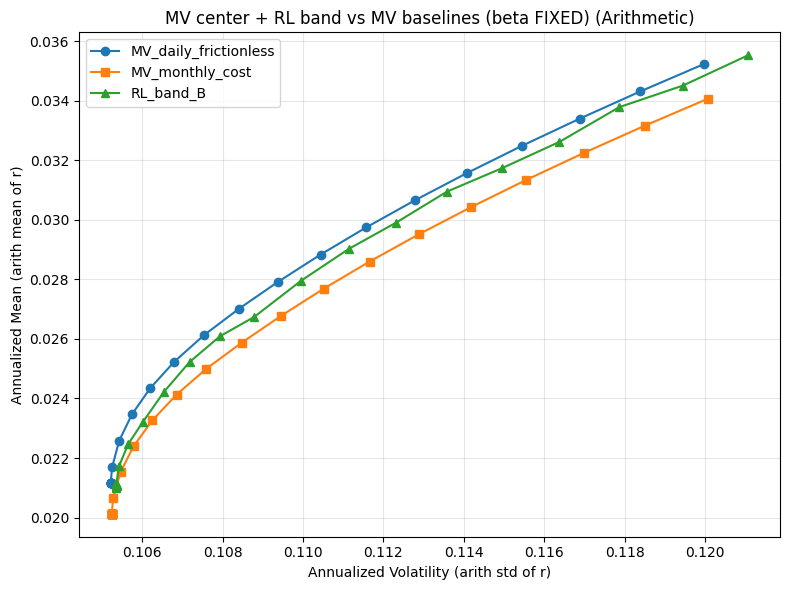

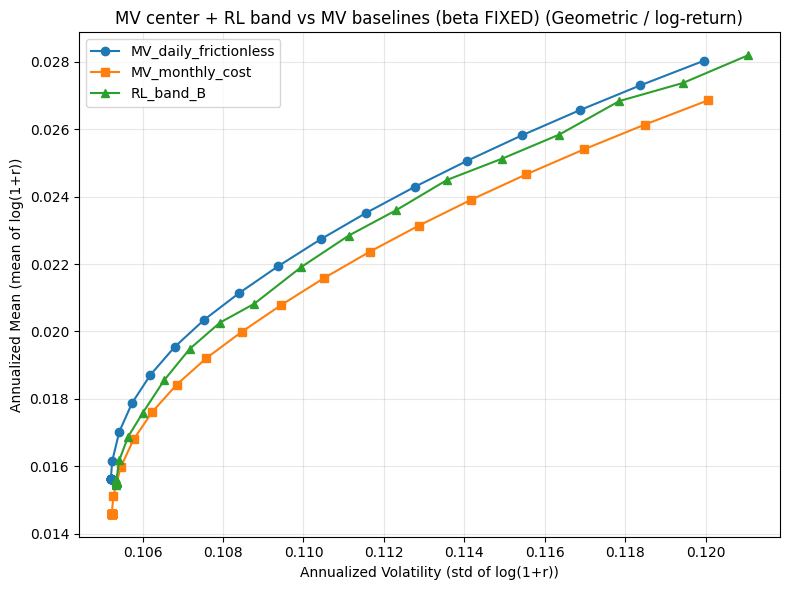

In [16]:
plot_frontier_two_v2(resA, resG, targets, title_prefix="MV center + RL band vs MV baselines (beta FIXED)")